In [79]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [80]:
REGION = 'Nord'
YEAR = 2023

In [81]:
grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', encoding=enc)
grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [82]:
grouped_file.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,27.31,36.32,18.29,15.33,43.85,0.0088,0.2720,0.2720,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31.0,36.0,30.0,12,12,3,5,8,29.58,20.67,55.86,349.57,52.0,15.0,37.0,26.17,29.33,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,27.29,35.32,19.27,15.81,43.15,0.0072,0.2226,0.2226,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31.0,36.0,30.0,12,12,3,5,8,29.17,18.83,53.81,326.37,50.0,15.0,35.0,25.83,29.00,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,26.94,34.50,19.38,16.44,42.65,0.0065,0.2013,0.2013,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31.0,36.0,30.0,12,12,3,5,8,29.50,19.33,55.24,311.89,51.0,16.0,35.0,27.00,28.67,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,26.46,35.17,17.75,15.64,41.99,0.0197,0.6118,0.6118,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31.0,36.0,30.0,12,12,3,5,8,29.33,18.83,57.07,296.44,48.0,15.0,33.0,26.83,27.83,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,27.43,34.46,20.40,17.91,42.08,0.0074,0.2300,0.2300,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31.0,36.0,30.0,12,12,3,5,8,29.88,19.08,59.64,263.82,49.0,17.0,32.0,27.50,29.17,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [83]:
grouped_file.shape

(1740, 74)

In [84]:
grouped_file_previous.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2022-01,2022,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.176122,-0.186515,-0.288388,0.186515,0.171239,-0.191422,-0.287672,0.191422,0.008860,0.018489,0.010070,0.018489,26.43,34.41,18.61,16.59,41.29,0.0044,0.1360,0.1360,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31.0,36,30.0,12,12,3,5,8,29.42,20.83,61.27,278.66,49.0,15.0,34.0,26.50,31.00,33.00,26.50,2434.0,571.0,0.0,107.78,1556.0,0.0,376.0,1556.0
1,2022-01,2022,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.183845,-0.154341,-0.297227,0.154341,0.177686,-0.152115,-0.288133,0.152115,0.012141,0.012280,0.014432,0.012280,26.49,34.00,19.07,16.25,40.20,0.0191,0.5929,0.5929,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31.0,36,30.0,12,12,3,5,8,29.12,19.75,59.85,281.33,48.0,15.0,33.0,26.33,30.67,32.67,25.67,2483.0,560.0,0.0,109.41,1623.0,0.0,383.0,1239.0
2,2022-01,2022,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.188846,-0.127586,-0.305740,0.127586,0.186665,-0.125383,-0.301822,0.125383,0.010090,0.010997,0.010728,0.010997,26.76,34.02,19.26,16.28,39.31,0.0016,0.0493,0.0493,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31.0,36,30.0,12,12,3,5,8,29.04,19.75,63.71,294.23,46.0,15.0,31.0,26.17,29.50,32.83,26.00,2347.0,547.0,0.0,111.96,1557.0,0.0,665.0,1135.0
3,2022-01,2022,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.199055,-0.146527,-0.276166,0.146527,0.199696,-0.153283,-0.281265,0.153283,0.018564,0.023534,0.016490,0.023534,24.76,31.88,17.64,15.11,39.49,0.0090,0.2791,0.2791,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31.0,36,30.0,12,12,3,5,8,29.42,19.67,61.46,308.83,47.0,15.0,32.0,26.67,29.67,33.67,26.50,2291.0,503.0,0.0,105.61,1436.0,0.0,690.0,1097.0
4,2022-01,2022,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.179243,-0.064322,-0.264258,0.064322,0.178863,-0.059794,-0.263958,0.059794,0.023544,0.021000,0.035657,0.021000,25.90,32.09,19.72,16.21,38.62,0.0019,0.0600,0.0600,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31.0,36,30.0,12,12,3,5,8,29.54,19.58,59.34,264.97,48.0,15.0,33.0,27.00,28.33,33.00,27.00,2327.0,576.0,0.0,112.97,1546.0,0.0,331.0,1546.0


In [85]:
grouped_file_previous.shape

(1740, 74)

In [86]:
grouped_file['dt_placement'] = pd.to_datetime(grouped_file['dt_placement'], errors='coerce').dt.to_period('M')
grouped_file_previous['dt_placement'] = pd.to_datetime(grouped_file_previous['dt_placement'], errors='coerce').dt.to_period('M')

In [87]:
grouped_file

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,27.31,36.32,18.29,15.33,43.85,0.0088,0.2720,0.2720,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31.0,36.0,30.0,12,12,3,5,8,29.58,20.67,55.86,349.57,52.0,15.0,37.0,26.17,29.33,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,27.29,35.32,19.27,15.81,43.15,0.0072,0.2226,0.2226,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31.0,36.0,30.0,12,12,3,5,8,29.17,18.83,53.81,326.37,50.0,15.0,35.0,25.83,29.00,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,26.94,34.50,19.38,16.44,42.65,0.0065,0.2013,0.2013,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31.0,36.0,30.0,12,12,3,5,8,29.50,19.33,55.24,311.89,51.0,16.0,35.0,27.00,28.67,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,26.46,35.17,17.75,15.64,41.99,0.0197,0.6118,0.6118,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31.0,36.0,30.0,12,12,3,5,8,29.33,18.83,57.07,296.44,48.0,15.0,33.0,26.83,27.83,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,27.43,34.46,20.40,17.91,42.08,0.0074,0.2300,0.2300,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31.0,36.0,30.0,12,12,3,5,8,29.88,19.08,59.64,263.82,49.0,17.0,32.0,27.50,29.17,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2023-12,2023,12,0.0,1.000,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,0.405491,0.015092,-0.335983,-0.015092,0.404507,0.018448,-0.335468,-0.018448,0.021516,0.026020,0.016624,0.026020,22.57,27.68,17.46,14.54,30.58,0.0274,0.8486,0.8486,125988.49,1351.46,5.49,165.60,710.63,180.16,0.0,416.45,9674.69,975.21,6.24,51.83,161.28,6.21,0.0,3164.67,22.0,20.0,20.0,9,9,4,4,4,25.75,15.00,50.00,291.94,44.0,14.0,30.0,23.33,25.17,29.67,23.33,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0
1736,2023-12,2023,12,0.0,1.000,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,0.364786,-0.031907,-0.352342,0.0319

In [88]:
biovars_temp = grouped_file_previous[['year', 'GID0', 'GID1', 'GID2', 'GID3'] + [col for col in grouped_file_previous.columns if 'bio' in col] ].copy()
biovars_temp.rename(columns={'year': 'year_biovars'}, inplace=True)

In [89]:
biovars_df = (
    biovars_temp
    .groupby(['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'])
    .mean(numeric_only=True)
    .reset_index()
    .round(2)
)

In [90]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2022,nord,benoue,bibemi,adoumri,29.42,20.83,61.27,278.66,49.0,15.0,34.0,26.50,31.00,33.00,26.50,2434.0,571.0,0.0,107.78,1556.0,0.0,376.0,1556.0
1,2022,nord,benoue,bibemi,bibemi,29.12,19.75,59.85,281.33,48.0,15.0,33.0,26.33,30.67,32.67,25.67,2483.0,560.0,0.0,109.41,1623.0,0.0,383.0,1239.0
2,2022,nord,benoue,bibemi,bide,29.04,19.75,63.71,294.23,46.0,15.0,31.0,26.17,29.50,32.83,26.00,2347.0,547.0,0.0,111.96,1557.0,0.0,665.0,1135.0
3,2022,nord,benoue,bibemi,dengui,29.42,19.67,61.46,308.83,47.0,15.0,32.0,26.67,29.67,33.67,26.50,2291.0,503.0,0.0,105.61,1436.0,0.0,690.0,1097.0
4,2022,nord,benoue,bibemi,djaloumi,29.54,19.58,59.34,264.97,48.0,15.0,33.0,27.00,28.33,33.00,27.00,2327.0,576.0,0.0,112.97,1546.0,0.0,331.0,1546.0


In [91]:
biovars_df.shape

(145, 24)

In [92]:
df_current = grouped_file.drop(columns=[col for col in grouped_file.columns if 'bio' in col]).copy()

In [93]:
df_current.shape

(1740, 55)

In [94]:
df_current['year_biovars'] = df_current['year']-1

In [95]:
df_current.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars
0,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,27.31,36.32,18.29,15.33,43.85,0.0088,0.2720,0.2720,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31.0,36.0,30.0,12,12,3,5,8,2022
1,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,27.29,35.32,19.27,15.81,43.15,0.0072,0.2226,0.2226,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31.0,36.0,30.0,12,12,3,5,8,2022
2,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,26.94,34.50,19.38,16.44,42.65,0.0065,0.2013,0.2013,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31.0,36.0,30.0,12,12,3,5,8,2022
3,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,26.46,35.17,17.75,15.64,41.99,0.0197,0.6118,0.6118,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31.0,36.0,30.0,12,12,3,5,8,2022
4,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,27.43,34.46,20.40,17.91,42.08,0.0074,0.2300,0.2300,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31.0,36.0,30.0,12,12,3,5,8,2022


In [96]:
df_current.shape

(1740, 56)

In [97]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2022,nord,benoue,bibemi,adoumri,29.42,20.83,61.27,278.66,49.0,15.0,34.0,26.50,31.00,33.00,26.50,2434.0,571.0,0.0,107.78,1556.0,0.0,376.0,1556.0
1,2022,nord,benoue,bibemi,bibemi,29.12,19.75,59.85,281.33,48.0,15.0,33.0,26.33,30.67,32.67,25.67,2483.0,560.0,0.0,109.41,1623.0,0.0,383.0,1239.0
2,2022,nord,benoue,bibemi,bide,29.04,19.75,63.71,294.23,46.0,15.0,31.0,26.17,29.50,32.83,26.00,2347.0,547.0,0.0,111.96,1557.0,0.0,665.0,1135.0
3,2022,nord,benoue,bibemi,dengui,29.42,19.67,61.46,308.83,47.0,15.0,32.0,26.67,29.67,33.67,26.50,2291.0,503.0,0.0,105.61,1436.0,0.0,690.0,1097.0
4,2022,nord,benoue,bibemi,djaloumi,29.54,19.58,59.34,264.97,48.0,15.0,33.0,27.00,28.33,33.00,27.00,2327.0,576.0,0.0,112.97,1546.0,0.0,331.0,1546.0


In [98]:
biovars_df.shape

(145, 24)

In [99]:
dataset = pd.merge(
    df_current, 
    biovars_df, 
    on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], 
    how='left'
)

In [100]:
dataset = pd.merge(df_current, biovars_df, on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], how='inner')

In [101]:
dataset.shape

(1740, 75)

<Axes: >

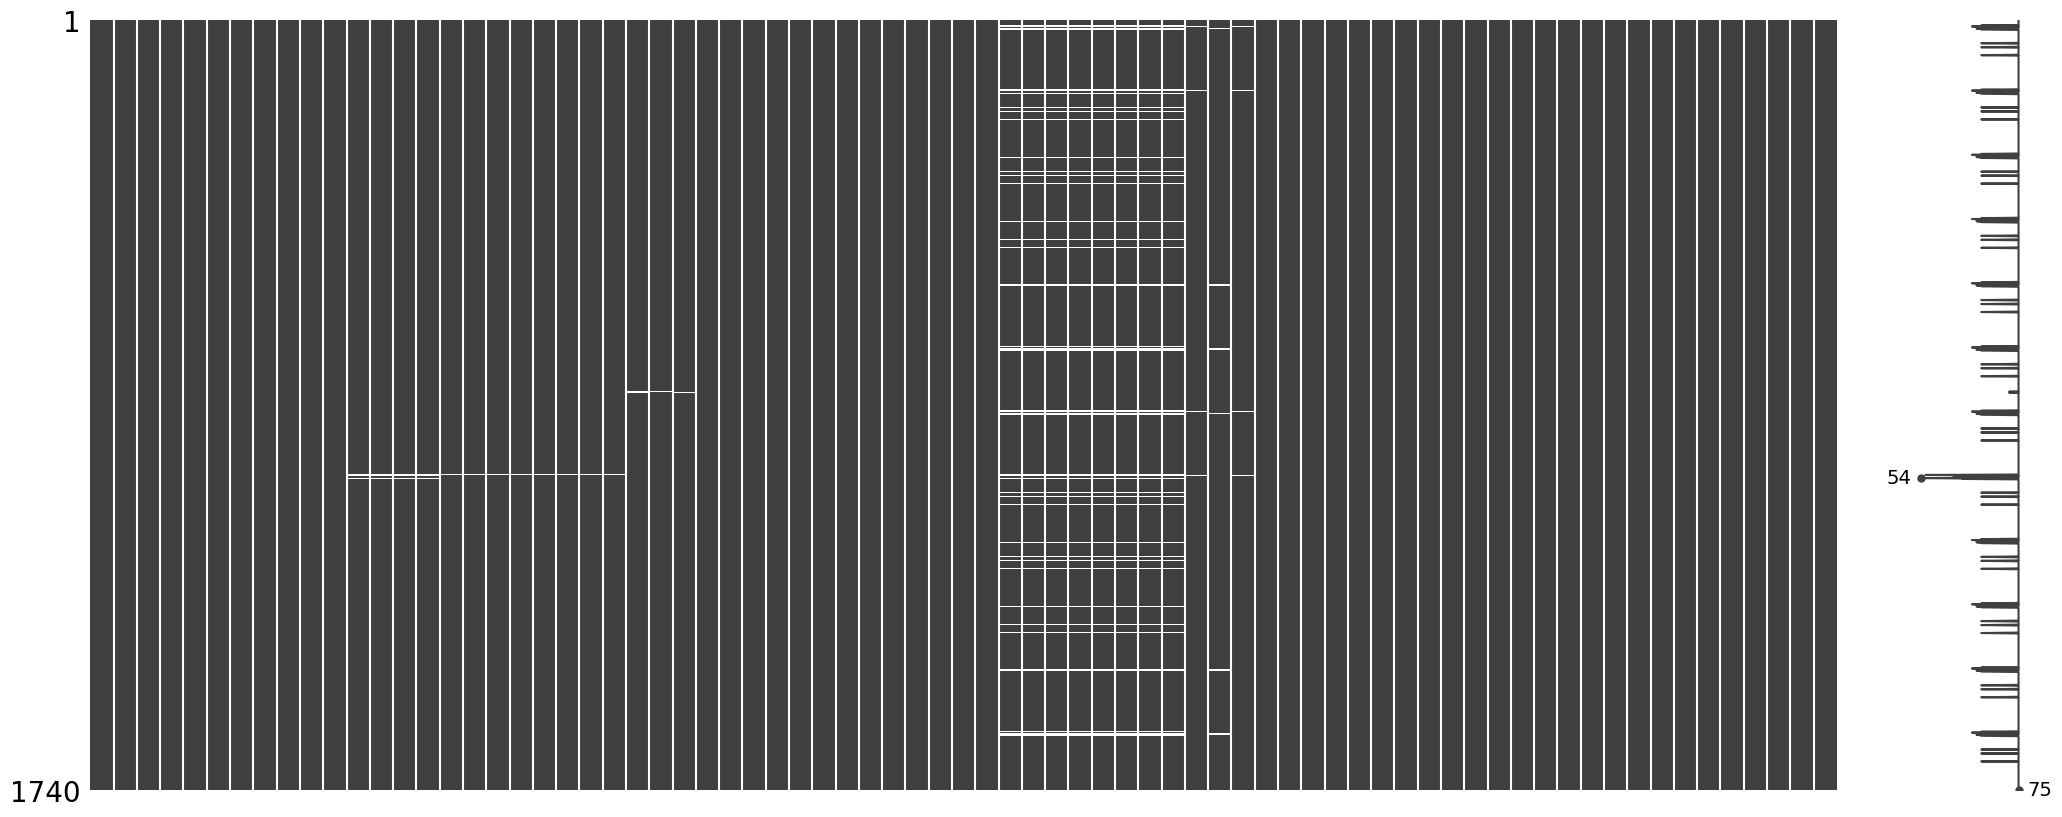

In [102]:
msno.matrix(dataset)

In [103]:
dataset

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,27.31,36.32,18.29,15.33,43.85,0.0088,0.2720,0.2720,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31.0,36.0,30.0,12,12,3,5,8,2022,29.42,20.83,61.27,278.66,49.0,15.0,34.0,26.50,31.00,33.00,26.50,2434.0,571.0,0.0,107.78,1556.0,0.0,376.0,1556.0
1,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,27.29,35.32,19.27,15.81,43.15,0.0072,0.2226,0.2226,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31.0,36.0,30.0,12,12,3,5,8,2022,29.12,19.75,59.85,281.33,48.0,15.0,33.0,26.33,30.67,32.67,25.67,2483.0,560.0,0.0,109.41,1623.0,0.0,383.0,1239.0
2,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,26.94,34.50,19.38,16.44,42.65,0.0065,0.2013,0.2013,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31.0,36.0,30.0,12,12,3,5,8,2022,29.04,19.75,63.71,294.23,46.0,15.0,31.0,26.17,29.50,32.83,26.00,2347.0,547.0,0.0,111.96,1557.0,0.0,665.0,1135.0
3,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,26.46,35.17,17.75,15.64,41.99,0.0197,0.6118,0.6118,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31.0,36.0,30.0,12,12,3,5,8,2022,29.42,19.67,61.46,308.83,47.0,15.0,32.0,26.67,29.67,33.67,26.50,2291.0,503.0,0.0,105.61,1436.0,0.0,690.0,1097.0
4,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,27.43,34.46,20.40,17.91,42.08,0.0074,0.2300,0.2300,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31.0,36.0,30.0,12,12,3,5,8,2022,29.54,19.58,59.34,264.97,48.0,15.0,33.0,27.00,28.33,33.00,27.00,2327.0,576.0,0.0,112.97,1546.0,0.0,331.0,1546.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2023-12,2023,12,0.0,1.000,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,0.405491,0.015092,-0.335983,-0.015092,0.404507,0.018448,-0.335468,-0.018448,0.021516,0.026020,0.016624,0.026020,22.57,27.68,17.46,14.54,30.58,0.0274,0.8486,0.8486,125988.49,1351.46,5.49,165.60,710.63,180.16,0.0,416.45,9674.69,975.21,6.24,51.83,161.28,6.21,0.0,3164.67,22.0,20.0,20.0,9,9,4,4,4,2022,25.21,16.75,50.76,348.02,44.0,11.0,33.0,22.17,25.33,30.17,22.00,3474.0,843.0,0.0,103.25,2137.0,0.0,365.0,1794.0
1736,2023-12,2023,12,0.0,1.000,nord,mayo-rey,touboro,ngai-lara,15.1

In [104]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc)